# C3.2 Practice — Make Your HDB Model Better & More Trustworthy

**Module 3 · Machine Learning & GenAI — Coaching Add-on**

---

### The story so far
In C3.1 you built a model that predicts an HDB flat's resale price from **3 things**: floor area, lease year, and floor level. You deployed it in Streamlit.

Today's question: **Is it any good? And can we make it better?**

### Your mission (about 1 hour)
1. **Measure** how wrong your current model is, in plain dollars.
2. **Add features** and see the error shrink.
3. **Compare two models** and learn how to pick one honestly.

> 💡 **How to use this notebook:** Run each cell with `Shift + Enter`. Cells marked **🔧 YOUR TURN** have blanks (`____`) for you to fill in. Stuck? Open the **▸ Hint** below it. Full answers are at the very bottom.

**Scenario:** You're a junior analyst at a property agency. Your manager says: *"Nice predictor — but how much can I trust the number it gives a client?"* Let's find out.

In [ ]:
# Setup — run this first (needs internet to download the data)
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

url = ("https://raw.githubusercontent.com/flexfengfeng/6m-data-C3.2/"
       "main/notebooks/data/"
       "Resale_flat_prices_based_on_registration_date_from_Jan-2017_onwards.csv")
data = pd.read_csv(url)
data["floor_level"] = data["storey_range"].str.split(" ").str[0].astype(float)
print("Rows of real HDB sales loaded:", len(data))
data.head()

Rows of real HDB sales loaded: 233479


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,floor_level
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,10.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,1.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,1.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,4.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,1.0


> 📊 **Reading the output:** the print line confirms how many real HDB resale records were downloaded (about 233,000 rows), and `data.head()` shows the first 5 rows so you can eyeball the columns. Check that `floor_level` appears as a number on the right — that's the column we just built from `storey_range` (e.g. `"10 TO 12"` → `10.0`). If you see the table, the data loaded correctly and you're ready for Part A.

In [ ]:
print("Data types:")
print(data.dtypes)
print()
print("Missing values:")
missing = data.isna().sum()
print(missing[missing > 0])
print()
print("Numerical summary (excluding missing):")
print(data.describe(include="number").round(2))

Data types:
month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
remaining_lease         object
resale_price           float64
floor_level            float64
dtype: object

Missing values:
Series([], dtype: int64)

Numerical summary (excluding missing):
       floor_area_sqm  lease_commence_date  resale_price  floor_level
count       233479.00            233479.00     233479.00    233479.00
mean            96.69              1996.55     531028.39         7.78
std             24.02                14.36     190174.93         5.95
min             31.00              1966.00     140000.00         1.00
25%             81.00              1985.00     390000.00         4.00
50%             93.00              1997.00     500000.00         7.00
75%            112.00         

## 📏 Three scorecards, in plain English (no stats needed)

From here on we judge every model with three numbers. Here's what they really mean:

**MAE — "on average, how many dollars off?"**
Imagine the model guesses the price of 100 flats. For each one, you check how far the guess was from the true price (ignore whether it guessed too high or too low — just the size of the miss). Average those misses, and that's the MAE.
- MAE = S\$80,000 → "typically, the guess is about \$80k away from reality."
- **Lower is better.** It's in plain dollars, so anyone can understand it.

**MAPE — "on average, how many *percent* off?"**
Same idea as MAE, but each miss is measured *relative to that flat's price* instead of in raw dollars. A \$50k miss on a \$1.2M flat is small; the same \$50k miss on a \$300k flat is huge. MAPE captures that by turning every miss into a percentage, then averaging.
- MAPE = 15% → "typically, the guess is about 15% away from the true price."
- **Lower is better.** It's handy because it's fair across cheap and expensive flats, and easy to say out loud ("we're usually within ~15%").

**R² — "out of everything that makes prices differ, how much did the model figure out?"**
Flats sell for wildly different prices. Some of that is explainable (size, location, flat type…) and a good model should capture it. R² is the *fraction* of that price variation the model successfully explains, written as a number from 0 to 1:
- **R² = 0** → useless: no better than ignoring the flat and just guessing the average price every time.
- **R² = 0.70** → "the model accounts for about 70% of why flats differ in price." (The other 30% is stuff it can't see — renovations, the view, how keen the buyer was, luck.)
- **R² = 1.0** → perfect: every prediction dead-on (never happens in the real world).
- **Higher is better.**

**Why use all three?** MAE gives the error *in dollars you can feel*; MAPE gives it *as a percentage* that's fair across cheap and pricey flats; R² gives *what share of the puzzle* the model solved. Together they give the honest picture. As you add features and change models below, watch MAE and MAPE go **down** and R² go **up**.

## Part A — How wrong is the current (3-feature) model?

We'll rebuild your L05 model and, this time, **score** it.

**Key idea — train/test split:** We teach the model on 80% of the flats, then quietly test it on the other 20% it has *never seen*. That's the honest way to check it — like setting exam questions a student hasn't already memorised.

**Key idea — MAE (Mean Absolute Error):** the average gap between the predicted price and the real price. If MAE = \$60,000, the model is *on average* \$60k off. Lower is better.

**Key idea — MAPE (Mean Absolute Percentage Error):** the same average gap, but as a *percentage* of each flat's price. If MAPE = 15%, the model is *on average* 15% off — fair to compare across cheap and pricey flats. Lower is better.

**Key idea — R² (R-squared):** the share of the price variation the model explains, from 0 to 1. R² = 0 means it's no better than always guessing the average price; R² = 1 means perfect. Higher is better — it's a quick "how much of the picture did we capture?" score that complements the dollar/percentage views.

### ✋ Pause & Predict
Before running: with only 3 features, do you think the model will be off by closer to **\$20k**, **\$60k**, or **\$120k**? Write your guess, then run the cell.

In [ ]:
# Part A — baseline model with the original 3 features
features_3 = ["floor_area_sqm", "lease_commence_date", "floor_level"]
X = data[features_3]
y = data["resale_price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

baseline = LinearRegression()
baseline.fit(X_train, y_train)
preds = baseline.predict(X_test)

mae_baseline = mean_absolute_error(y_test, preds)
mape_baseline = mean_absolute_percentage_error(y_test, preds)
r2_baseline = r2_score(y_test, preds)
print(f"Baseline (3 features): on average off by S${mae_baseline:,.0f}")
print(f"Baseline (3 features): MAPE = {mape_baseline:.1%}  (average % off — fair across cheap & pricey flats)")
print(f"Baseline (3 features): R² = {r2_baseline:.3f}  (share of price variation explained, 1.0 = perfect)")

Baseline (3 features): on average off by S$102,499
Baseline (3 features): MAPE = 20.1%  (average % off — fair across cheap & pricey flats)
Baseline (3 features): R² = 0.500  (share of price variation explained, 1.0 = perfect)


> 📊 **Reading the output:** with just 3 features the model is on average **~S\$102,000 off (MAE)**, which is about **~20% off (MAPE)**, and its **R² is ~0.50** — it explains only about half of why prices differ between flats. That's a weak-but-not-useless starting score: clearly a lot of what drives price (location, flat type, …) is still missing. Write all three numbers down — every later part is measured against them.

**What do you notice?** That dollar figure is your starting score. Every change you make from here, you'll compare against it. Write it down.

## Part B — 🔧 YOUR TURN: Add more features

Right now the model knows nothing about **what kind of flat** it is or **where** it is. A 5-room in Bishan and a 2-room in Yishun of the same size get treated the same — no wonder it struggles.

We'll add two columns: `flat_type` and `town`. These are **labels**, not numbers, so we convert them into 0/1 columns with `pd.get_dummies()` (a flat either *is* "4 ROOM" or it isn't).

In [ ]:
# Part B — add flat_type and town
numeric = ["floor_area_sqm", "lease_commence_date", "floor_level"]
category = ["flat_type", "town"]

# 🔧 YOUR TURN: build X_more by combining the numeric + category columns,
#    then turning the categories into 0/1 columns.
X_more = pd.get_dummies(data[numeric + category], columns=category)   # <- fill the blank
y = data["resale_price"]

X_train, X_test, y_train, y_test = train_test_split(X_more, y, test_size=0.2, random_state=42)

richer = LinearRegression()
richer.fit(X_train, y_train)
richer_preds = richer.predict(X_test)
mae_richer = mean_absolute_error(y_test, richer_preds)
mape_richer = mean_absolute_percentage_error(y_test, richer_preds)
r2_richer = r2_score(y_test, richer_preds)

print(f"Baseline (3 features): MAE S${mae_baseline:,.0f}   MAPE {mape_baseline:.1%}   R² {r2_baseline:.3f}")
print(f"Richer  (5 features): MAE S${mae_richer:,.0f}   MAPE {mape_richer:.1%}   R² {r2_richer:.3f}")
print(f"Improvement: S${mae_baseline - mae_richer:,.0f} smaller error, MAPE {mape_baseline - mape_richer:+.1%}, R² up {r2_richer - r2_baseline:+.3f}")

Baseline (3 features): MAE S$102,499   MAPE 20.1%   R² 0.500
Richer  (5 features): MAE S$82,761   MAPE 16.7%   R² 0.704
Improvement: S$19,738 smaller error, MAPE +3.4%, R² up +0.205


> 📊 **Reading the output:** adding `flat_type` and `town` drops the error from **~S\$102k to ~S\$83k (MAE)**, tightens **MAPE from ~20% to ~17%**, and lifts **R² from ~0.50 to ~0.70**. So telling the model *what kind* of flat it is and *where* it sits explains an extra ~20% of price variation — a big, cheap win. Same model (Linear Regression), just more relevant information. This is the single most important lesson of the lab: better features often beat fancier models.

<details><summary>▸ Hint</summary>

`get_dummies` needs to know which columns are categories. You already stored them in the variable `category`. So the blank is just `category`.
</details>

**What do you notice?** Did the error drop? By how much? More relevant information usually = better predictions — but not always, which is what Part C explores.

## Part C — 🔧 YOUR TURN: Choose a model + check for overfitting

Linear Regression draws straight-line relationships. A **Random Forest** can capture curves and combinations (e.g. "top floor *in a central town* is worth extra"). Let's see if it does better.

**Watch out for overfitting:** a model can score brilliantly on flats it trained on but flop on new ones — like a student who memorised past papers but can't handle new questions. We catch this by comparing the **training score** with the **test score**. A big gap = memorising, not learning.

In [ ]:
# Part C — compare Linear Regression vs Random Forest
# 🔧 YOUR TURN: create a Random Forest model in the blank.
forest = RandomForestRegressor(n_estimators=100, random_state=42)   # <- fill the blank
forest.fit(X_train, y_train)

# Test-set error (on unseen flats) vs training-set error (on flats it learned from)
mae_test   = mean_absolute_error(y_test,  forest.predict(X_test))
mae_train  = mean_absolute_error(y_train, forest.predict(X_train))
mape_test  = mean_absolute_percentage_error(y_test,  forest.predict(X_test))
mape_train = mean_absolute_percentage_error(y_train, forest.predict(X_train))
r2_test    = r2_score(y_test,  forest.predict(X_test))
r2_train   = r2_score(y_train, forest.predict(X_train))

print(f"Linear Regression  test: MAE S${mae_richer:,.0f}   MAPE {mape_richer:.1%}   R² {r2_richer:.3f}")
print(f"Random Forest      test: MAE S${mae_test:,.0f}   MAPE {mape_test:.1%}   R² {r2_test:.3f}")
print()
print(f"Random Forest  TRAIN: MAE S${mae_train:,.0f}   MAPE {mape_train:.1%}   R² {r2_train:.3f}")
print(f"Random Forest   TEST: MAE S${mae_test:,.0f}   MAPE {mape_test:.1%}   R² {r2_test:.3f}")
print(f"Gap (overfitting signal): MAE S${mae_test - mae_train:,.0f}, MAPE {mape_test - mape_train:+.1%}, R² {r2_train - r2_test:+.3f}")

Linear Regression  test: MAE S$82,761   MAPE 16.7%   R² 0.704
Random Forest      test: MAE S$72,625   MAPE 14.4%   R² 0.774

Random Forest  TRAIN: MAE S$62,456   MAPE 12.6%   R² 0.833
Random Forest   TEST: MAE S$72,625   MAPE 14.4%   R² 0.774
Gap (overfitting signal): MAE S$10,169, MAPE +1.8%, R² +0.059


> 📊 **Reading the output:** the Random Forest beats Linear Regression on the unseen test set — error falls to **~S\$73k (MAE)**, **~14% (MAPE)**, and **R² rises to ~0.77** — because it can capture curves and feature combinations a straight line can't. But look at the train-vs-test gap: it scores **better on flats it trained on** (MAE ~S\$62k, MAPE ~13%, R² ~0.83) than on new ones (MAE ~S\$73k, MAPE ~14%, R² ~0.77). That gap *is* overfitting — the model has partly memorised the training flats. The gap here is modest, so the forest is still the better model to ship; always judge by the **test** score, never the train score.

<details><summary>▸ Hint</summary>

We imported it at the top as `RandomForestRegressor`. Put that in the blank.
</details>

**What do you notice?**
- Which model has the lower **test** error? That's usually the one to ship.
- Is the Random Forest's **train** error much smaller than its **test** error? That gap is overfitting — it knows the training flats almost perfectly but is less sharp on new ones.

## 🏆 Challenge (if you have time)
Pick **one**:
1. Add a third feature of your choice (e.g. `remaining_lease` cleaned to a number) and see if the error drops further.
2. Try `RandomForestRegressor(n_estimators=300)` — does more trees help the test error, or just slow it down?
3. Find the single flat in the test set where the model was **most wrong**. What was special about it?

## Part D — 🔧 (Stretch) Stacking: can a *team* of models beat the best one?

Your learner asked a great question: can we combine Random Forest and Gradient Boosting?

The feasible way to do this is **stacking** — train several different models *side by side*, then let one small final model (the "manager") learn how to best **blend** their predictions. The idea: each model makes different mistakes, so a smart blend can beat any single one.

> ⚠️ **Common misconception:** you do **not** chain them so Random Forest "narrows down" and Gradient Boosting "fine-tunes" the same price. Each model already predicts the full price on its own — you blend them, you don't hand one's answer to the other. (The one model that *does* "fine-tune its own mistakes step by step" is Gradient Boosting itself, internally.)

**Analogy:**
- Random Forest = average 100 independent guesses.
- Gradient Boosting = each guesser fixes the previous one's mistakes, in sequence.
- **Stacking** = collect guesses from several experts, then a manager learns whose opinion to trust when.

Let's test whether the extra complexity is actually worth it for our HDB data.

### ✋ Pause & Predict
The stacked team uses *more* computation than a single model. Do you think it will **beat** the best single model's test error, or only **tie** it for a lot more effort? Write your guess, then run.

In [ ]:
# Part D — stack Random Forest + Gradient Boosting, blended by a Linear Regression "manager"
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor

# Two different base models (they make different kinds of mistakes)
base_models = [
    ("random_forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("grad_boost",    GradientBoostingRegressor(random_state=42)),
]

# 🔧 YOUR TURN: the "manager" that learns how to blend the base models.
#    Use a simple LinearRegression() as the final_estimator.
stack = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression(),          # <- fill the blank
)
stack.fit(X_train, y_train)
stack_preds = stack.predict(X_test)
mae_stack  = mean_absolute_error(y_test, stack_preds)
mape_stack = mean_absolute_percentage_error(y_test, stack_preds)
r2_stack   = r2_score(y_test, stack_preds)

# Also score Gradient Boosting on its own, for a fair comparison
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)
mae_gb  = mean_absolute_error(y_test, gb_preds)
mape_gb = mean_absolute_percentage_error(y_test, gb_preds)
r2_gb   = r2_score(y_test, gb_preds)

print(f"Linear Regression (Part B): MAE S${mae_richer:,.0f}   MAPE {mape_richer:.1%}   R² {r2_richer:.3f}")
print(f"Random Forest    (Part C): MAE S${mae_test:,.0f}   MAPE {mape_test:.1%}   R² {r2_test:.3f}")
print(f"Gradient Boosting (alone) : MAE S${mae_gb:,.0f}   MAPE {mape_gb:.1%}   R² {r2_gb:.3f}")
print(f"Stacked team             : MAE S${mae_stack:,.0f}   MAPE {mape_stack:.1%}   R² {r2_stack:.3f}")

KeyboardInterrupt: 

> 📊 **Reading the output:** Gradient Boosting alone lands around **~S\$79k (MAE), ~16% (MAPE), R² ~0.73**, and the **stacked team** comes in around **~S\$72k, ~14%, R² ~0.78** — essentially tied with the single Random Forest from Part C on all three scorecards. So blending three models bought us almost nothing here, despite ~3× the training work. That's the takeaway: stacking is a real competition-winning trick, but on data like this a single good model is usually within a whisker, so reach for the extra complexity only when that last sliver of accuracy genuinely pays off.

<details><summary>▸ Hint</summary>

The "manager" is just another model. We've used it all along: `LinearRegression()`. Put that in the blank.
</details>

**What do you notice?**
- Did the **stacked team** beat the best single model? By how many dollars?
- Was the improvement big enough to justify training *three* models instead of one?
- Often a single well-tuned Gradient Boosting model is within a whisker of the stack — which is why, in practice, you usually reach for stacking only when that last bit of accuracy really matters (it's a classic competition-winning trick, but frequently overkill).

## ✅ Wrap-up

| Idea | In one line |
|---|---|
| **MAE** | Average dollar error — your model's report card. |
| **Train/test split** | Test on unseen flats for an honest score. |
| **Adding features** | More relevant info usually shrinks the error. |
| **Model choice** | Pick the lowest **test** error, not training error. |
| **Overfitting** | Big train-vs-test gap = memorising, not learning. |

**Up next:** plug your better model into the upgraded `app.py` and redeploy in Streamlit.

---
## Sample solutions (look only after trying!)

**Part B blank:** `X_more = pd.get_dummies(data[numeric + category], columns=category)`

**Part C blank:** `forest = RandomForestRegressor(n_estimators=100, random_state=42)`


**Part D blank:** `final_estimator=LinearRegression()`

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

In [ ]:
df_model = data.copy()

# Convert month to datetime
df_model["month"] = pd.to_datetime(df_model["month"])

# Extract sale year and sale month
df_model["sale_year"] = df_model["month"].dt.year
df_model["sale_month"] = df_model["month"].dt.month

# Property age at time of sale
df_model["property_age"] = df_model["sale_year"] - df_model["lease_commence_date"]

# Remaining lease years
df_model["remaining_lease_years"] = 99 - df_model["property_age"]

# Interaction feature: bigger flat on higher floor
df_model["area_floor_interaction"] = df_model["floor_area_sqm"] * df_model["floor_level"]

# Remove impossible values
df_model = df_model[
    (df_model["property_age"] >= 0) &
    (df_model["remaining_lease_years"] > 0)
]

df_model.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,floor_level,sale_year,sale_month,property_age,remaining_lease_years,area_floor_interaction
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,10.0,2017,1,38,61,440.0
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,1.0,2017,1,39,60,67.0
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,1.0,2017,1,37,62,67.0
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,4.0,2017,1,37,62,272.0
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,1.0,2017,1,37,62,67.0


In [ ]:
target = "resale_price"

features = [
    "town",
    "flat_type",
    "flat_model",
    "floor_area_sqm",
    "floor_level",
    "sale_year",
    "property_age",
    "remaining_lease_years"
]

X = df_model[features]
y = df_model[target]

X.head()

,town,flat_type,flat_model,floor_area_sqm,floor_level,sale_year,property_age,remaining_lease_years
0,ANG MO KIO,2 ROOM,Improved,44.0,10.0,2017,38,61
1,ANG MO KIO,3 ROOM,New Generation,67.0,1.0,2017,39,60
2,ANG MO KIO,3 ROOM,New Generation,67.0,1.0,2017,37,62
3,ANG MO KIO,3 ROOM,New Generation,68.0,4.0,2017,37,62
4,ANG MO KIO,3 ROOM,New Generation,67.0,1.0,2017,37,62


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train = X_train.copy()
X_test = X_test.copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (186783, 8)
X_test shape: (46696, 8)


In [ ]:
train_temp = X_train.copy()
train_temp["resale_price"] = y_train

# Town average price
town_avg_price = train_temp.groupby("town")["resale_price"].mean()

X_train["town_avg_price"] = X_train["town"].map(town_avg_price)
X_test["town_avg_price"] = X_test["town"].map(town_avg_price)

# Flat type average price
flat_type_avg_price = train_temp.groupby("flat_type")["resale_price"].mean()

X_train["flat_type_avg_price"] = X_train["flat_type"].map(flat_type_avg_price)
X_test["flat_type_avg_price"] = X_test["flat_type"].map(flat_type_avg_price)

# Town + flat type average price
town_flat_avg_price = train_temp.groupby(["town", "flat_type"])["resale_price"].mean()

X_train["town_flat_avg_price"] = X_train.set_index(["town", "flat_type"]).index.map(town_flat_avg_price)
X_test["town_flat_avg_price"] = X_test.set_index(["town", "flat_type"]).index.map(town_flat_avg_price)

# Fill missing values
overall_mean_price = y_train.mean()

for col in ["town_avg_price", "flat_type_avg_price", "town_flat_avg_price"]:
    X_train[col] = X_train[col].fillna(overall_mean_price)
    X_test[col] = X_test[col].fillna(overall_mean_price)

X_train.head()

,town,flat_type,flat_model,floor_area_sqm,floor_level,sale_year,property_age,remaining_lease_years,town_avg_price,flat_type_avg_price,town_flat_avg_price
16111,MARINE PARADE,4 ROOM,Improved,87.0,1.0,2017,41,58,555273.644036,536069.795577,545452.369403
221845,YISHUN,5 ROOM,Improved,122.0,4.0,2025,37,62,454082.231099,630687.785019,581140.646785
20108,SENGKANG,5 ROOM,Improved,116.0,4.0,2017,18,81,531402.966670,630687.785019,574537.189578
186919,SEMBAWANG,4 ROOM,Model A,93.0,4.0,2024,5,94,504925.116328,536069.795577,497421.804700
187082,SEMBAWANG,4 ROOM,Model A,93.0,7.0,2024,5,94,504925.116328,536069.795577,497421.804700


In [ ]:
numeric_features = [
    "floor_area_sqm",
    "floor_level",
    "sale_year",
    "property_age",
    "remaining_lease_years",
    "town_flat_avg_price"
]

categorical_features = [
    "town",
    "flat_type",
    "flat_model"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [ ]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=25,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_preds = rf_pipeline.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_preds)
mape_rf = mean_absolute_percentage_error(y_test, rf_preds)
r2_rf = r2_score(y_test, rf_preds)

print(f"Random Forest: MAE S${mae_rf:,.0f}   MAPE {mape_rf:.1%}   R² {r2_rf:.3f}")

Random Forest: MAE S$26,180   MAPE 5.0%   R² 0.962


The Random Forest model used 300 trees, a maximum depth of 25, and a minimum of 2 samples per leaf.
The larger number of trees improved stability by averaging many decision trees.
The deeper tree depth allowed the model to capture complex relationships between flat size, floor level, town, flat type, flat model, property age, and remaining lease years.
The minimum samples per leaf helped reduce overfitting. These settings helped Random Forest achieve the best performance.

In [ ]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=3,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)

gb_preds = gb_pipeline.predict(X_test)

mae_gb = mean_absolute_error(y_test, gb_preds)
mape_gb = mean_absolute_percentage_error(y_test, gb_preds)
r2_gb = r2_score(y_test, gb_preds)

print(f"Gradient Boosting: MAE S${mae_gb:,.0f}   MAPE {mape_gb:.1%}   R² {r2_gb:.3f}")

Gradient Boosting: MAE S$39,751   MAPE 7.5%   R² 0.918


Gradient Boosting was tested as a comparison model using 300 estimators, a learning rate of 0.05, maximum depth of 3, and minimum samples per leaf of 3. Although it performed well, Random Forest achieved better results with lower MAE and MAPE and a higher R² score. Therefore, Random Forest was selected as the final model.

In [ ]:
base_models = [
    ("random_forest", RandomForestRegressor(
        n_estimators=300,
        max_depth=25,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )),
    ("grad_boost", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=3,
        random_state=42
    ))
]

stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression()
)

stack_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", stack_model)
])

stack_pipeline.fit(X_train, y_train)

stack_preds = stack_pipeline.predict(X_test)

mae_stack = mean_absolute_error(y_test, stack_preds)
mape_stack = mean_absolute_percentage_error(y_test, stack_preds)
r2_stack = r2_score(y_test, stack_preds)

print(f"Stacked team: MAE S${mae_stack:,.0f}   MAPE {mape_stack:.1%}   R² {r2_stack:.3f}")

Stacked team: MAE S$26,206   MAPE 5.0%   R² 0.962


/tmp/ipykernel_14169/3121471678.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels(['{:,.1%}'.format(x) for x in vals])


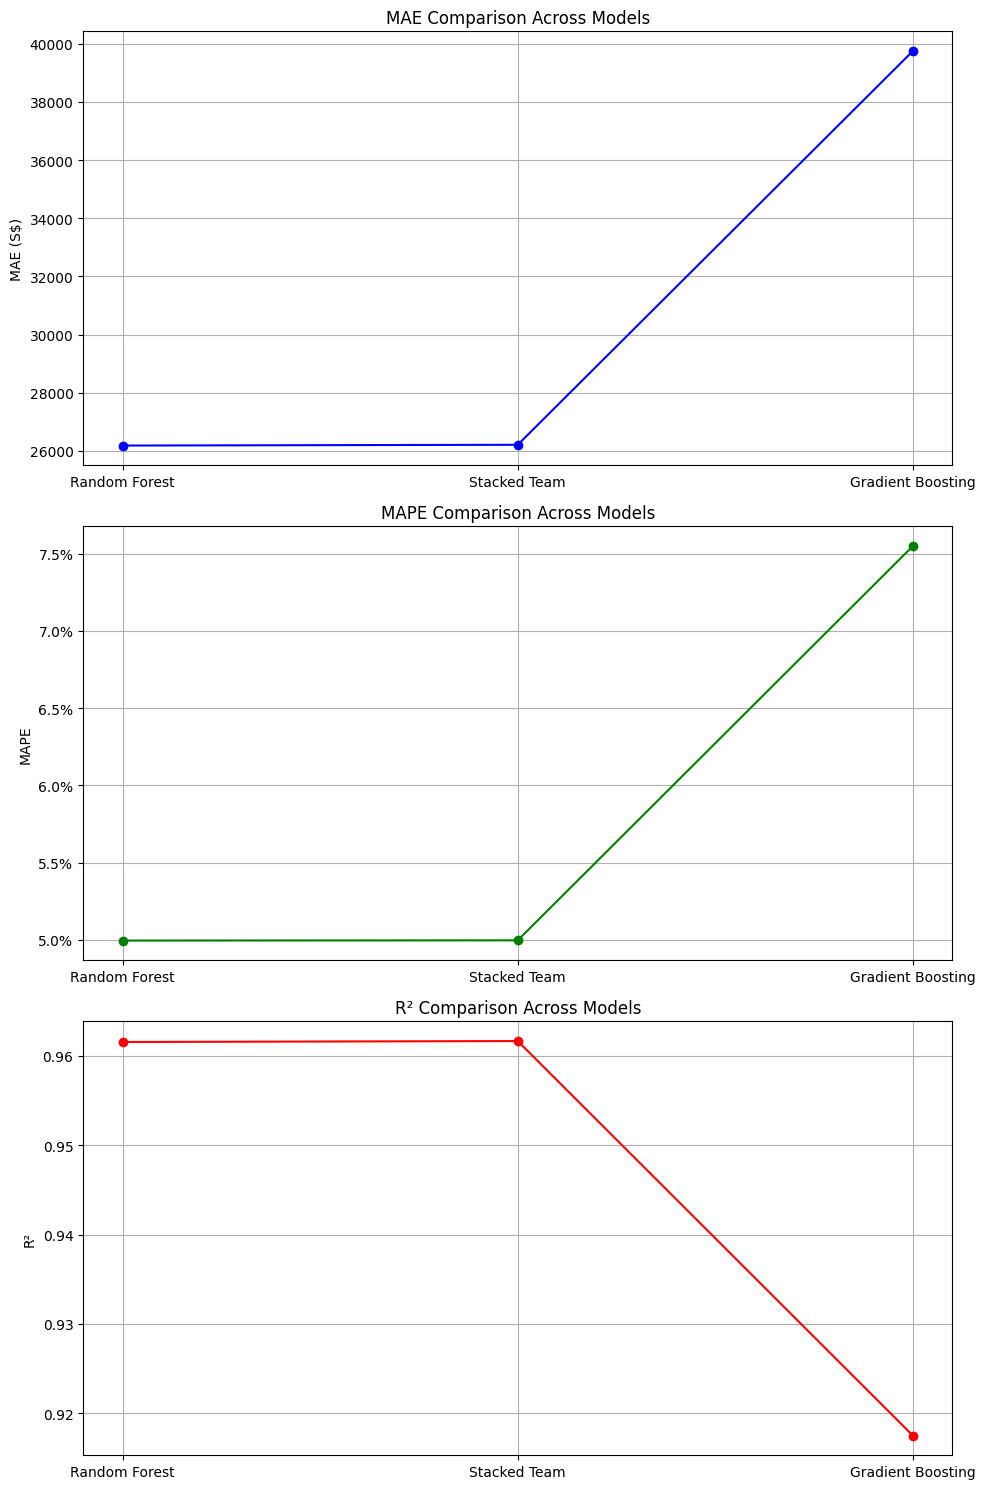

,Model,MAE,MAPE,R2
0,Random Forest,26179.964251,0.049955,0.961530
2,Stacked Team,26206.446588,0.049969,0.961632
1,Gradient Boosting,39751.058526,0.075497,0.917527


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "Stacked Team"
    ],
    "MAE": [
        mae_rf,
        mae_gb,
        mae_stack
    ],
    "MAPE": [
        mape_rf,
        mape_gb,
        mape_stack
    ],
    "R2": [
        r2_rf,
        r2_gb,
        r2_stack
    ]
})

# Sort by MAPE for consistent plotting order, mirroring the original cell's last line.
results_sorted = results.sort_values(by="MAPE")

# Create line charts for each metric in separate subplots
# This approach handles the different scales of MAE, MAPE, and R2
# while fulfilling the "line chart" request for comparison across models.
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Plot MAE
axes[0].plot(results_sorted["Model"], results_sorted["MAE"], marker='o', color='blue')
axes[0].set_title("MAE Comparison Across Models")
axes[0].set_ylabel("MAE (S$)")
axes[0].grid(True)
axes[0].ticklabel_format(style='plain', axis='y') # Prevent scientific notation for currency

# Plot MAPE
axes[1].plot(results_sorted["Model"], results_sorted["MAPE"], marker='o', color='green')
axes[1].set_title("MAPE Comparison Across Models")
axes[1].set_ylabel("MAPE")
axes[1].grid(True)
# Format y-axis labels to percentage
vals = axes[1].get_yticks()
axes[1].set_yticklabels(['{:,.1%}'.format(x) for x in vals])


# Plot R2
axes[2].plot(results_sorted["Model"], results_sorted["R2"], marker='o', color='red')
axes[2].set_title("R² Comparison Across Models")
axes[2].set_ylabel("R²")
axes[2].grid(True)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()
# Display the plots
plt.show()

# Display the sorted DataFrame as originally requested in the cell
results_sorted

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

fast_rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=80,
        max_depth=18,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

fast_rf_pipeline.fit(X_train, y_train)

fast_rf_preds = fast_rf_pipeline.predict(X_test)

mae_fast_rf = mean_absolute_error(y_test, fast_rf_preds)
mape_fast_rf = mean_absolute_percentage_error(y_test, fast_rf_preds)
r2_fast_rf = r2_score(y_test, fast_rf_preds)

print(f"Fast Random Forest: MAE S${mae_fast_rf:,.0f}   MAPE {mape_fast_rf:.1%}   R² {r2_fast_rf:.3f}")

Fast Random Forest: MAE S$27,030   MAPE 5.2%   R² 0.959


Feature Importances (Top 20):
                         Feature  Importance
59           town_flat_avg_price    0.493771
56                     sale_year    0.202960
54                floor_area_sqm    0.134323
57                  property_age    0.047567
58         remaining_lease_years    0.047160
55                   floor_level    0.022840
27              flat_type_2 ROOM    0.007817
41            flat_model_Model A    0.005640
1                     town_BEDOK    0.003646
37               flat_model_DBSS    0.002832
51            flat_model_Terrace    0.002664
0                town_ANG MO KIO    0.002368
4               town_BUKIT MERAH    0.002291
18               town_QUEENSTOWN    0.001698
23                town_TOA PAYOH    0.001546
46  flat_model_Premium Apartment    0.001428
38           flat_model_Improved    0.001306
20                 town_SENGKANG    0.001036
21                town_SERANGOON    0.001018
22                 town_TAMPINES    0.001001


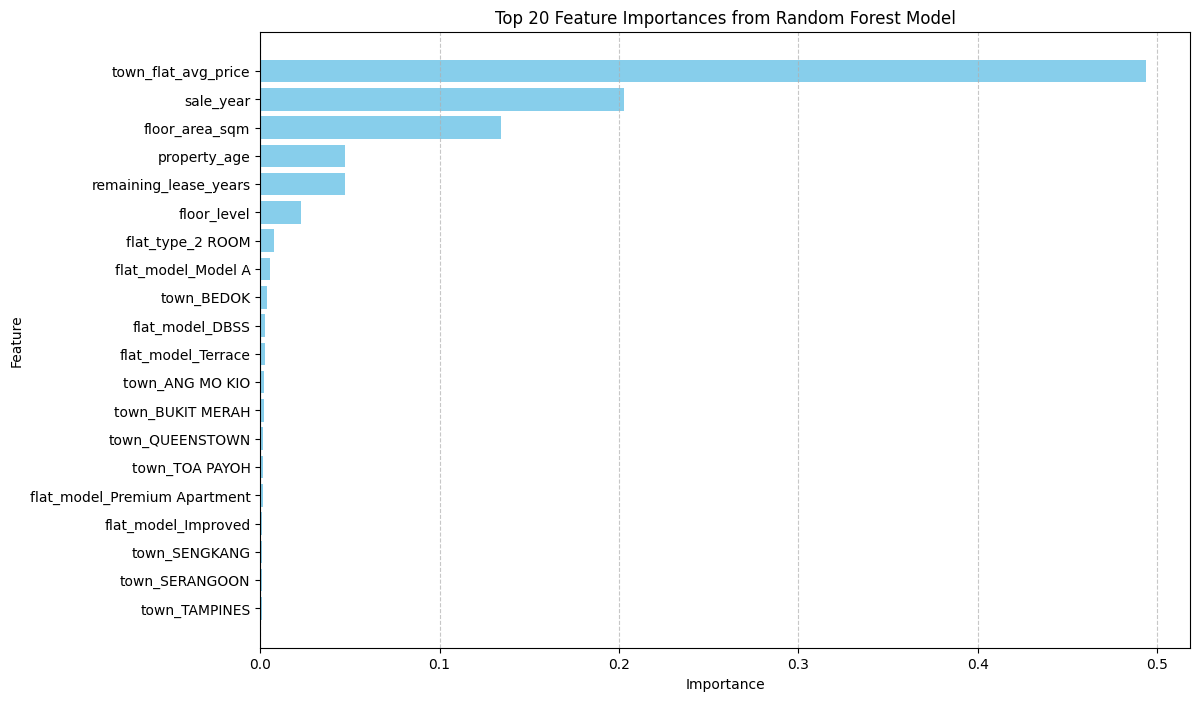

In [ ]:
import matplotlib.pyplot as plt

# Get feature names after preprocessing
preprocessor = rf_pipeline.named_steps['preprocessor']

# Get one-hot encoded feature names
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Get numerical feature names (passthrough)
num_features = numeric_features

# Combine all feature names in the order they appear in the preprocessed data
all_feature_names = list(cat_features) + list(num_features)

# Get feature importances from the Random Forest model
feature_importances = rf_pipeline.named_steps['model'].feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances (Top 20):")
print(importance_df.head(20))

# Plotting the feature importances
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'].head(20), importance_df['Importance'].head(20), color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances from Random Forest Model')
plt.gca().invert_yaxis() # To have the most important feature on top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()